# **Libraries**

In [1]:
import numpy as np
import pandas as pd

# Mount Drive
from google.colab import drive

# Prepare Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# cVAE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import time
from sklearn.decomposition import PCA

# XGBoost
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            confusion_matrix, classification_report)
import warnings

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


# **Prepare Dataset**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/cleaned_25features_all.csv")

In [ ]:
df.head()

,PercentDifferenceFluxPercentile,Freq1_harmonics_amplitude_0,Meanvariance,PeriodLS_0,StetsonK_AC,Skew,Std,Amplitude,Rcs,Psi_eta_0,...,StetsonK,Autocor_length,FluxPercentileRatioMid50,AndersonDarling,FluxPercentileRatioMid65,Psi_CS_0,MedianAbsDev,Freq1_harmonics_amplitude_1,Beyond1Std,label
0,0.093965,0.306130,0.028682,297.456012,0.825241,-0.203652,0.478722,0.88550,0.088605,1.179267,...,0.797193,1.0,0.435587,0.85623,0.602041,0.204634,0.3440,0.120154,0.354680,var_Cataclysmic
1,0.122192,0.217150,0.036408,0.963788,0.760384,-1.177735,0.559093,1.12900,0.069157,1.872192,...,0.758991,1.0,0.316711,1.00000,0.471618,0.091739,0.2995,0.062729,0.364486,var_Cataclysmic
2,0.102245,0.177785,0.031158,0.491907,0.731720,-1.641033,0.532418,1.19825,0.074431,1.560145,...,0.719822,1.0,0.275014,1.00000,0.413951,0.131171,0.2370,0.142050,0.381166,var_Cataclysmic
3,0.075147,0.119638,0.027242,0.078062,0.729589,-3.261180,0.420262,0.66700,0.072364,1.819163,...,0.600220,1.0,0.235043,1.00000,0.552137,0.075280,0.1045,0.019772,0.332524,var_Cataclysmic
4,0.102542,0.295051,0.031667,176.849350,0.796719,-0.833826,0.546931,0.98250,0.076650,1.064748,...,0.732743,1.0,0.427370,1.00000,0.559731,0.175268,0.3590,0.162672,0.482143,var_Cataclysmic


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543311 entries, 0 to 543310
Data columns (total 26 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   PercentDifferenceFluxPercentile  543311 non-null  float64
 1   Freq1_harmonics_amplitude_0      543311 non-null  float64
 2   Meanvariance                     543311 non-null  float64
 3   PeriodLS_0                       543311 non-null  float64
 4   StetsonK_AC                      543311 non-null  float64
 5   Skew                             543311 non-null  float64
 6   Std                              543311 non-null  float64
 7   Amplitude                        543311 non-null  float64
 8   Rcs                              543311 non-null  float64
 9   Psi_eta_0                        543311 non-null  float64
 10  Mean                             543311 non-null  float64
 11  CAR_mean                         543311 non-null  float64
 12  Gs

In [ ]:
df.describe()

,PercentDifferenceFluxPercentile,Freq1_harmonics_amplitude_0,Meanvariance,PeriodLS_0,StetsonK_AC,Skew,Std,Amplitude,Rcs,Psi_eta_0,...,PercentAmplitude,StetsonK,Autocor_length,FluxPercentileRatioMid50,AndersonDarling,FluxPercentileRatioMid65,Psi_CS_0,MedianAbsDev,Freq1_harmonics_amplitude_1,Beyond1Std
count,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,...,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000,543311.000000
mean,0.034326,0.181726,0.011154,328.831066,0.767902,0.542304,0.158481,0.287333,0.082579,1.023319,...,0.041280,0.781367,1.011264,0.404244,0.930600,0.557939,0.202184,0.093926,0.059384,0.290733
std,0.040816,0.570743,0.013381,1734.586721,0.078929,1.554179,0.182080,0.314011,0.026145,0.571718,...,0.056308,0.078632,0.238455,0.110454,0.165181,0.125241,0.063403,0.123760,0.160184,0.088283
min,0.001604,0.001359,0.000553,0.001529,0.196607,-21.473932,0.006479,0.011000,0.001490,0.001075,...,0.001468,0.132085,1.000000,0.003338,0.097621,0.006490,0.030273,0.004000,0.000024,0.001582
25%,0.013718,0.044643,0.004332,0.374779,0.728639,-0.104350,0.059495,0.111500,0.064137,0.507462,...,0.014573,0.759732,1.000000,0.357351,0.980857,0.513158,0.155934,0.033000,0.009739,0.256318
50%,0.023893,0.087788,0.007603,1.004711,0.772848,0.239813,0.107112,0.197250,0.079032,1.060131,...,0.025934,0.796474,1.000000,0.409992,0.999999,0.571429,0.198244,0.061000,0.023987,0.303030
75%,0.040151,0.169525,0.012899,80.517032,0.820981,0.696397,0.185839,0.340500,0.096967,1.512052,...,0.046009,0.826917,1.000000,0.464348,1.000000,0.629089,0.240364,0.110000,0.058871,0.341187
max,2.661191,63.965110,0.612754,25109.987500,0.999727,22.630825,6.286891,8.466000,0.380512,3.034225,...,2.686721,0.997741,100.000000,0.986546,1.000000,0.990961,0.498871,2.618000,16.342957,0.712821


In [ ]:
df["label"].value_counts()

,count
label,
var_Semiregular,195052
var_EclipsingBinary,149910
var_Irregular,94543
var_RRLyrae,44286
var_Rotational,35004
var_Mira,10230
var_DeltaScuti,8537
var_Cepheid,3696
var_Cataclysmic,2053


In [ ]:
label_column = ["label"]

In [ ]:
# Separate features and labels

X = df.drop(columns=label_column)
y = df[label_column]

print(f"\n✓ Features shape: {X.shape} (should be (n_samples, 25))")
print(f"✓ Labels shape: {y.shape}")


✓ Features shape: (543311, 25) (should be (n_samples, 25))
✓ Labels shape: (543311, 1)


In [ ]:
# Split into train and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,  # 80% train, 20% validation
    random_state=42,
    stratify=y  # Keep class proportions
)

In [ ]:
# Normalize/Standardize features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"✓ Features standardized (mean=0, std=1)")
print(f"Training set mean: {X_train_scaled.mean():.6f}")
print(f"Training set std: {X_train_scaled.std():.6f}")

✓ Features standardized (mean=0, std=1)
Training set mean: 0.000000
Training set std: 1.000000


In [ ]:
# Encode labels

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)
print(f"✓ Labels encoded to integers (0 to {num_classes-1})")
print(f"Number of classes: {num_classes}")
print(f"\nClass mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


✓ Labels encoded to integers (0 to 8)
Number of classes: 9

Class mapping:
  0: var_Cataclysmic
  1: var_Cepheid
  2: var_DeltaScuti
  3: var_EclipsingBinary
  4: var_Irregular
  5: var_Mira
  6: var_RRLyrae
  7: var_Rotational
  8: var_Semiregular


In [ ]:
print("\n💾 Saving prepared data...")
prepared_data = {
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'y_train': y_train_encoded,
    'y_val': y_val_encoded,
    'scaler': scaler,
    'label_encoder': label_encoder,
    'num_features': X_train_scaled.shape[1],
    'num_classes': num_classes,
    'feature_names': X.columns.tolist()
}

print("✓ Data prepared and ready for modeling!")


💾 Saving prepared data...
✓ Data prepared and ready for modeling!


In [ ]:
# Define the save path
save_path = '/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/prepared_data.joblib'

# Save the dictionary
joblib.dump(prepared_data, save_path)

print(f"✓ saved prepared_data to: {save_path}")

✓ saved prepared_data to: /content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/prepared_data.joblib


# **cVAE**

In [ ]:
# ระบุ path ของไฟล์ที่บันทึกไว้
load_path = '/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/prepared_data.joblib'

# โหลดข้อมูลกลับมา
loaded_data = joblib.load(load_path)

# ตรวจสอบ key ต่างๆ ใน dictionary
print("Keys in loaded data:", loaded_data.keys())
print(f"Number of classes: {loaded_data['num_classes']}")
print(f"Number of features: {loaded_data['num_features']}")

Keys in loaded data: dict_keys(['X_train', 'X_val', 'y_train', 'y_val', 'scaler', 'label_encoder', 'num_features', 'num_classes', 'feature_names'])
Number of classes: 9
Number of features: 25


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Using device: {device}")


🖥️ Using device: cuda


## **Define**

In [ ]:
# Define hyperparameters

LATENT_DIM = 10          # Size of latent space (you can adjust this)
HIDDEN_DIM = 128         # Size of hidden layers
LEARNING_RATE = 1e-3     # Learning rate for optimizer
BATCH_SIZE = 64          # Batch size for training
NUM_EPOCHS = 100         # Number of training epochs
BETA = 1.0               # Weight for KL divergence (β-VAE)

num_features = loaded_data['num_features']
num_classes = loaded_data['num_classes']

print(f"Input features: {num_features}")
print(f"Number of classes: {num_classes}")
print(f"Latent dimension: {LATENT_DIM}")
print(f"Hidden dimension: {HIDDEN_DIM}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")

Input features: 25
Number of classes: 9
Latent dimension: 10
Hidden dimension: 128
Batch size: 64
Learning rate: 0.001


In [ ]:
# Create Dataset class

class LightCurveDataset(Dataset):
    """Custom dataset for light curve features with labels"""
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets
train_dataset = LightCurveDataset(loaded_data['X_train'], loaded_data['y_train'])
val_dataset = LightCurveDataset(loaded_data['X_val'], loaded_data['y_val'])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ Training batches: {len(train_loader)}")
print(f"✓ Validation batches: {len(val_loader)}")

✓ Training batches: 6792
✓ Validation batches: 1698


In [ ]:
# Define the Encoder

class Encoder(nn.Module):
    """Encoder: Takes features + condition → outputs mean and log_variance"""
    def __init__(self, input_dim, condition_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()

        # Input: features + one-hot encoded condition
        self.fc1 = nn.Linear(input_dim + condition_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        # Output: mean and log variance of latent distribution
        self.fc_mean = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, c):
        """
        Args:
            x: features [batch_size, input_dim]
            c: condition (one-hot) [batch_size, condition_dim]
        Returns:
            mean, log_variance
        """
        # Concatenate features and condition
        xc = torch.cat([x, c], dim=1)

        # Pass through network
        h = F.relu(self.fc1(xc))
        h = F.relu(self.fc2(h))

        # Get mean and log variance
        mean = self.fc_mean(h)
        logvar = self.fc_logvar(h)

        return mean, logvar

print("✓ Encoder defined")
print(f"  Input: features ({num_features}) + condition ({num_classes})")
print(f"  Hidden layers: {HIDDEN_DIM} neurons")
print(f"  Output: mean ({LATENT_DIM}) + log_var ({LATENT_DIM})")

✓ Encoder defined
  Input: features (25) + condition (9)
  Hidden layers: 128 neurons
  Output: mean (10) + log_var (10)


In [ ]:
# Define the Decoder

class Decoder(nn.Module):
    """Decoder: Takes latent sample + condition → reconstructs features"""
    def __init__(self, latent_dim, condition_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()

        # Input: latent sample + one-hot encoded condition
        self.fc1 = nn.Linear(latent_dim + condition_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, c):
        """
        Args:
            z: latent sample [batch_size, latent_dim]
            c: condition (one-hot) [batch_size, condition_dim]
        Returns:
            reconstructed features
        """
        # Concatenate latent sample and condition
        zc = torch.cat([z, c], dim=1)

        # Pass through network
        h = F.relu(self.fc1(zc))
        h = F.relu(self.fc2(h))
        x_recon = self.fc3(h)  # No activation - let it be any value

        return x_recon

print("✓ Decoder defined")
print(f"  Input: latent ({LATENT_DIM}) + condition ({num_classes})")
print(f"  Hidden layers: {HIDDEN_DIM} neurons")
print(f"  Output: reconstructed features ({num_features})")

✓ Decoder defined
  Input: latent (10) + condition (9)
  Hidden layers: 128 neurons
  Output: reconstructed features (25)


In [ ]:
# Define the complete cVAE

class cVAE(nn.Module):
    """Conditional Variational Autoencoder"""
    def __init__(self, input_dim, condition_dim, hidden_dim, latent_dim):
        super(cVAE, self).__init__()

        self.encoder = Encoder(input_dim, condition_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, condition_dim, hidden_dim, input_dim)
        self.condition_dim = condition_dim

    def reparameterize(self, mean, logvar):
        """
        Reparameterization trick: z = mean + std * epsilon
        where epsilon ~ N(0, 1)
        """
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mean + std * epsilon
        return z

    def forward(self, x, c):
        """
        Forward pass through cVAE
        Args:
            x: features
            c: condition labels (integer indices)
        Returns:
            x_recon: reconstructed features
            mean: latent mean
            logvar: latent log variance
        """
        # Convert condition to one-hot encoding
        c_onehot = F.one_hot(c, num_classes=self.condition_dim).float()

        # Encode
        mean, logvar = self.encoder(x, c_onehot)

        # Sample from latent distribution
        z = self.reparameterize(mean, logvar)

        # Decode
        x_recon = self.decoder(z, c_onehot)

        return x_recon, mean, logvar

    def generate(self, num_samples, condition, device):
        """
        Generate new samples
        Args:
            num_samples: number of samples to generate
            condition: class label (integer)
            device: torch device
        Returns:
            generated features
        """
        self.eval()
        with torch.no_grad():
            # Sample from standard normal
            z = torch.randn(num_samples, LATENT_DIM).to(device)

            # Create condition
            c = torch.tensor([condition] * num_samples).to(device)
            c_onehot = F.one_hot(c, num_classes=self.condition_dim).float()

            # Generate
            x_gen = self.decoder(z, c_onehot)

        return x_gen.cpu().numpy()

In [ ]:
# Define loss function

def cvae_loss(x_recon, x, mean, logvar, beta=1.0):
    """
    cVAE loss = Reconstruction Loss + β * KL Divergence

    Args:
        x_recon: reconstructed features
        x: original features
        mean: latent mean
        logvar: latent log variance
        beta: weight for KL divergence (β-VAE)
    """
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')

    # KL divergence: KL(N(mean, var) || N(0, 1))
    # Formula: -0.5 * sum(1 + log(var) - mean^2 - var)
    kl_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

print("✓ Loss function defined:")
print("  Total Loss = Reconstruction Loss + β * KL Divergence")
print(f"  β (beta) = {BETA}")

✓ Loss function defined:
  Total Loss = Reconstruction Loss + β * KL Divergence
  β (beta) = 1.0


In [ ]:
# Initialize model

model = cVAE(
    input_dim=num_features,
    condition_dim=num_classes,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model created and moved to {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

✓ Model created and moved to cuda
Total parameters: 45,869
Trainable parameters: 45,869


In [ ]:
# Define optimizer

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\n✓ Optimizer: Adam with learning rate {LEARNING_RATE}")


✓ Optimizer: Adam with learning rate 0.001


In [ ]:
# Save model configuration for next steps
model_config = {
    'model': model,
    'optimizer': optimizer,
    'train_loader': train_loader,
    'val_loader': val_loader,
    'device': device,
    'num_epochs': NUM_EPOCHS,
    'beta': BETA
}

## **Training**

In [ ]:
print(f"✅ GPU is available!")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Current device: {device}")

✅ GPU is available!
GPU Name: Tesla T4
GPU Memory: 15.83 GB
Current device: cuda


In [ ]:
# Clear cache
torch.cuda.empty_cache()
print("✓ GPU cache cleared")

✓ GPU cache cleared


In [ ]:
# Training function

def train_epoch(model, train_loader, optimizer, device, beta):
    """Train for one epoch"""
    model.train()
    train_loss = 0
    train_recon_loss = 0
    train_kl_loss = 0

    # Progress bar
    pbar = tqdm(train_loader, desc='Training', leave=False)

    for batch_idx, (features, labels) in enumerate(pbar):
        # Move data to device
        features = features.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        x_recon, mean, logvar = model(features, labels)

        # Calculate loss
        loss, recon_loss, kl_loss = cvae_loss(x_recon, features, mean, logvar, beta)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Accumulate losses
        train_loss += loss.item()
        train_recon_loss += recon_loss.item()
        train_kl_loss += kl_loss.item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item()/len(features):.4f}',
            'recon': f'{recon_loss.item()/len(features):.4f}',
            'kl': f'{kl_loss.item()/len(features):.4f}'
        })

    # Average losses
    n_samples = len(train_loader.dataset)
    avg_loss = train_loss / n_samples
    avg_recon = train_recon_loss / n_samples
    avg_kl = train_kl_loss / n_samples

    return avg_loss, avg_recon, avg_kl

In [ ]:
# Validation function

def validate_epoch(model, val_loader, device, beta):
    """Validate for one epoch"""
    model.eval()
    val_loss = 0
    val_recon_loss = 0
    val_kl_loss = 0

    with torch.no_grad():
        for features, labels in val_loader:
            # Move data to device
            features = features.to(device)
            labels = labels.to(device)

            # Forward pass
            x_recon, mean, logvar = model(features, labels)

            # Calculate loss
            loss, recon_loss, kl_loss = cvae_loss(x_recon, features, mean, logvar, beta)

            # Accumulate losses
            val_loss += loss.item()
            val_recon_loss += recon_loss.item()
            val_kl_loss += kl_loss.item()

    # Average losses
    n_samples = len(val_loader.dataset)
    avg_loss = val_loss / n_samples
    avg_recon = val_recon_loss / n_samples
    avg_kl = val_kl_loss / n_samples

    return avg_loss, avg_recon, avg_kl

In [ ]:
# Training loop

print("\n🚀 Starting training...")
print(f"Total epochs: {model_config['num_epochs']}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Device: {device}")

# Training history
history = {
    'train_loss': [],
    'train_recon': [],
    'train_kl': [],
    'val_loss': [],
    'val_recon': [],
    'val_kl': [],
    'epochs': []
}

# Best model tracking
best_val_loss = float('inf')
best_epoch = 0
patience = 20  # Early stopping patience
patience_counter = 0

# Training loop
start_time = time.time()

for epoch in range(1, model_config['num_epochs'] + 1):
    # Train
    train_loss, train_recon, train_kl = train_epoch(
        model, train_loader, optimizer, device, model_config['beta']
    )

    # Validate
    val_loss, val_recon, val_kl = validate_epoch(
        model, val_loader, device, model_config['beta']
    )

    # Save history
    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['val_loss'].append(val_loss)
    history['val_recon'].append(val_recon)
    history['val_kl'].append(val_kl)
    history['epochs'].append(epoch)

    # Print progress every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"\nEpoch {epoch}/{model_config['num_epochs']}")
        print(f"  Train Loss: {train_loss:.4f} (Recon: {train_recon:.4f}, KL: {train_kl:.4f})")
        print(f"  Val Loss:   {val_loss:.4f} (Recon: {val_recon:.4f}, KL: {val_kl:.4f})")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0

        # Save model checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'history': history
        }, 'best_cvae_model.pth')

        if epoch % 5 == 0 or epoch == 1:
            print(f"  ✓ Best model saved! (Val loss: {val_loss:.4f})")
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping triggered at epoch {epoch}")
        print(f"Best model was at epoch {best_epoch} with val loss: {best_val_loss:.4f}")
        break

training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time/60:.2f} minutes")
print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")


🚀 Starting training...
Total epochs: 100
Batch size: 64
Device: cuda



Epoch 1/100
  Train Loss: 9.1925 (Recon: 5.6832, KL: 3.5093)
  Val Loss:   8.0804 (Recon: 4.5972, KL: 3.4831)
  ✓ Best model saved! (Val loss: 8.0804)



Epoch 5/100
  Train Loss: 7.4740 (Recon: 3.9877, KL: 3.4863)
  Val Loss:   8.9954 (Recon: 5.3847, KL: 3.6107)



Epoch 10/100
  Train Loss: 7.3584 (Recon: 3.8804, KL: 3.4780)
  Val Loss:   7.3021 (Recon: 3.7492, KL: 3.5528)
  ✓ Best model saved! (Val loss: 7.3021)



Epoch 15/100
  Train Loss: 7.2661 (Recon: 3.8068, KL: 3.4593)
  Val Loss:   7.2808 (Recon: 3.7684, KL: 3.5124)
  ✓ Best model saved! (Val loss: 7.2808)


...


Epoch 65/100
  Train Loss: 7.1878 (Recon: 3.7534, KL: 3.4345)
  Val Loss:   7.9955 (Recon: 4.4061, KL: 3.5895)



Epoch 70/100
  Train Loss: 7.2925 (Recon: 3.8544, KL: 3.4381)
  Val Loss:   9.2658 (Recon: 4.7184, KL: 4.5475)



Epoch 75/100
  Train Loss: 7.1800 (Recon: 3.7374, KL: 3.4426)
  Val Loss:   7.2948 (Recon: 3.8260, KL: 3.4688)



Epoch 80/100
  Train Loss: 7.1303 (Recon: 3.6992, KL: 3.4311)
  Val Loss:   7.4581 (Recon: 3.9415, KL: 3.5166)



⏹️ Early stopping triggered at epoch 83
Best model was at epoch 63 with val loss: 7.1525

✅ Training completed in 52.05 minutes
Best validation loss: 7.1525 at epoch 63


In [ ]:
# Load best model
print("\n📦 Loading best model...")
checkpoint = torch.load('best_cvae_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print("✓ Best model loaded!")


📦 Loading best model...
✓ Best model loaded!



📊 Plotting training history...


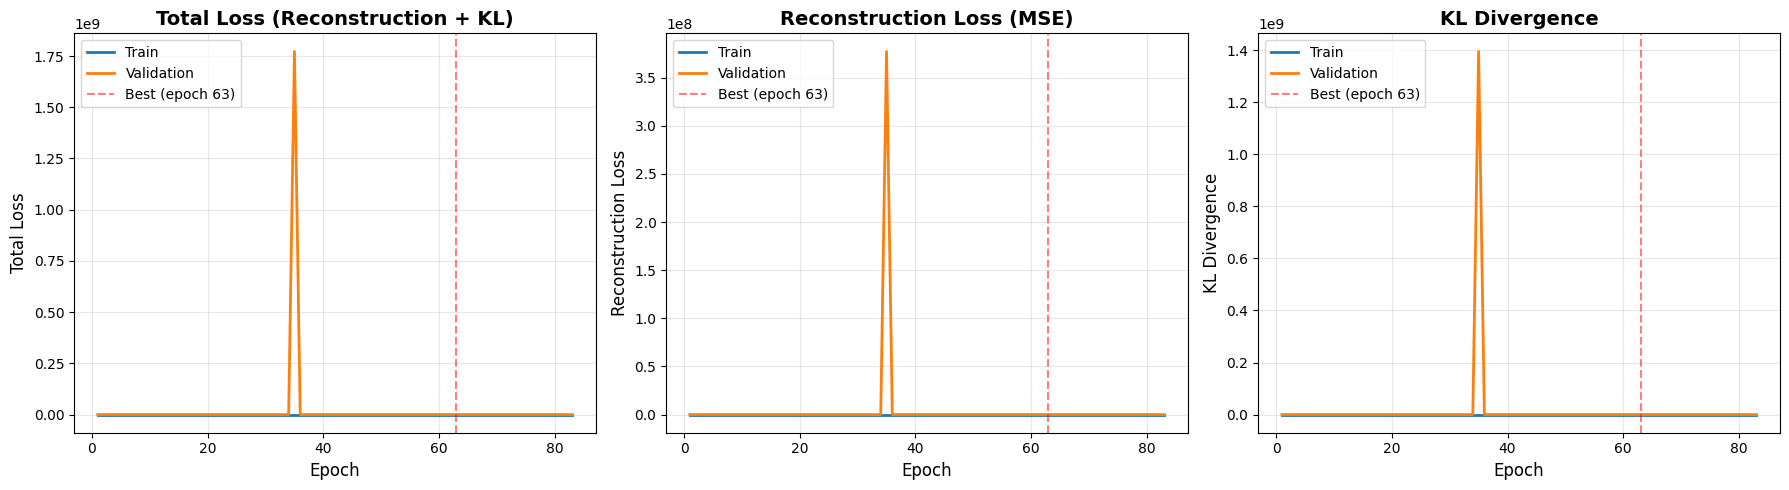

✓ Training history plot saved as 'training_history.png'


In [ ]:
# Plot training history
print("\n📊 Plotting training history...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total loss
axes[0].plot(history['epochs'], history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['epochs'], history['val_loss'], label='Validation', linewidth=2)
axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Total Loss', fontsize=12)
axes[0].set_title('Total Loss (Reconstruction + KL)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(history['epochs'], history['train_recon'], label='Train', linewidth=2)
axes[1].plot(history['epochs'], history['val_recon'], label='Validation', linewidth=2)
axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Reconstruction Loss', fontsize=12)
axes[1].set_title('Reconstruction Loss (MSE)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL divergence
axes[2].plot(history['epochs'], history['train_kl'], label='Train', linewidth=2)
axes[2].plot(history['epochs'], history['val_kl'], label='Validation', linewidth=2)
axes[2].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('KL Divergence', fontsize=12)
axes[2].set_title('KL Divergence', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history plot saved as 'training_history.png'")

In [ ]:
# Save training results for next steps
training_results = {
    'model': model,
    'history': history,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
    'checkpoint_path': 'best_cvae_model.pth',
    'device': device
}

## **Generate Data**

In [ ]:
# 4.1 Display available classes

print("\n📋 Available Classes:")
print("="*60)

label_encoder = loaded_data['label_encoder']
class_names = label_encoder.classes_

for idx, class_name in enumerate(class_names):
    # Count real samples
    real_count = np.sum(loaded_data['y_train'] == idx) + np.sum(loaded_data['y_val'] == idx)
    print(f"{idx}: {class_name} (Real samples: {real_count})")


📋 Available Classes:
0: var_Cataclysmic (Real samples: 2053)
1: var_Cepheid (Real samples: 3696)
2: var_DeltaScuti (Real samples: 8537)
3: var_EclipsingBinary (Real samples: 149910)
4: var_Irregular (Real samples: 94543)
5: var_Mira (Real samples: 10230)
6: var_RRLyrae (Real samples: 44286)
7: var_Rotational (Real samples: 35004)
8: var_Semiregular (Real samples: 195052)


In [ ]:
# 4.2 Configure generation settings

synthetic_counts = {}

# Balance dataset
real_counts = []
for idx in range(len(class_names)):
    count = np.sum(loaded_data['y_train'] == idx) + np.sum(loaded_data['y_val'] == idx)
    real_counts.append(count)

max_count = max(real_counts)
print(f"\nLargest class has {max_count} samples")
print("Generating synthetic data to balance all classes to this amount...")

for idx, class_name in enumerate(class_names):
    synthetic_counts[idx] = max_count - real_counts[idx]

total_synthetic = 0

for idx, class_name in enumerate(class_names):
    count = synthetic_counts[idx]
    total_synthetic += count
    print(f"{class_name}: {count} samples")
print(f"\nTotal synthetic samples to generate: {total_synthetic}")

# Confirm
confirm = input("\nProceed with generation? (y/n): ").strip().lower()
if confirm != 'y':
    print("Generation cancelled.")
    exit()


Largest class has 195052 samples
Generating synthetic data to balance all classes to this amount...
var_Cataclysmic: 192999 samples
var_Cepheid: 191356 samples
var_DeltaScuti: 186515 samples
var_EclipsingBinary: 45142 samples
var_Irregular: 100509 samples
var_Mira: 184822 samples
var_RRLyrae: 150766 samples
var_Rotational: 160048 samples
var_Semiregular: 0 samples

Total synthetic samples to generate: 1212157

Proceed with generation? (y/n): y


In [ ]:
# 4.3 Generate synthetic data
print("\n" + "="*60)
print("🎨 GENERATING SYNTHETIC DATA")
print("="*60)

model.eval()  # Set model to evaluation mode
synthetic_features_list = []
synthetic_labels_list = []

print("\nGenerating samples...")
for class_idx, count in synthetic_counts.items():
    if count > 0:
        class_name = class_names[class_idx]
        print(f"  Generating {count} samples for class '{class_name}'...")

        # Generate synthetic features (scaled)
        synthetic_scaled = model.generate(
            num_samples=count,
            condition=class_idx,
            device=device
        )

        synthetic_features_list.append(synthetic_scaled)
        synthetic_labels_list.append(np.array([class_idx] * count))

# Concatenate all synthetic data
synthetic_features_scaled = np.vstack(synthetic_features_list)
synthetic_labels_encoded = np.concatenate(synthetic_labels_list)

print(f"\n✓ Generated {len(synthetic_features_scaled)} synthetic samples")


🎨 GENERATING SYNTHETIC DATA

Generating samples...
  Generating 192999 samples for class 'var_Cataclysmic'...
  Generating 191356 samples for class 'var_Cepheid'...
  Generating 186515 samples for class 'var_DeltaScuti'...
  Generating 45142 samples for class 'var_EclipsingBinary'...
  Generating 100509 samples for class 'var_Irregular'...
  Generating 184822 samples for class 'var_Mira'...
  Generating 150766 samples for class 'var_RRLyrae'...
  Generating 160048 samples for class 'var_Rotational'...

✓ Generated 1212157 synthetic samples


In [ ]:
# 4.4 Inverse transform to original scale
print("\n" + "="*60)
print("🔄 INVERSE TRANSFORMING TO ORIGINAL SCALE")
print("="*60)

scaler = loaded_data['scaler']
synthetic_features = scaler.inverse_transform(synthetic_features_scaled)

print("✓ Features transformed back to original scale")

# Decode labels back to original names
synthetic_labels = label_encoder.inverse_transform(synthetic_labels_encoded)

print("✓ Labels decoded to original names")


🔄 INVERSE TRANSFORMING TO ORIGINAL SCALE
✓ Features transformed back to original scale
✓ Labels decoded to original names


In [ ]:
# 4.5 Create DataFrame
print("\n" + "="*60)
print("📊 CREATING SYNTHETIC DATASET")
print("="*60)

feature_names = loaded_data['feature_names']
synthetic_df = pd.DataFrame(synthetic_features, columns=feature_names)
synthetic_df['label'] = synthetic_labels

synthetic_df.head()


📊 CREATING SYNTHETIC DATASET


,PercentDifferenceFluxPercentile,Freq1_harmonics_amplitude_0,Meanvariance,PeriodLS_0,StetsonK_AC,Skew,Std,Amplitude,Rcs,Psi_eta_0,...,StetsonK,Autocor_length,FluxPercentileRatioMid50,AndersonDarling,FluxPercentileRatioMid65,Psi_CS_0,MedianAbsDev,Freq1_harmonics_amplitude_1,Beyond1Std,label
0,0.073930,0.295853,0.027051,1915.504150,0.761724,-0.479496,0.288798,0.599598,0.083447,0.714505,...,0.780830,1.026237,0.329014,0.972238,0.487449,0.279450,0.086100,0.146278,0.225234,var_Cataclysmic
1,0.018280,0.045273,0.007585,128.415695,0.673929,-1.029145,0.113992,0.253532,0.103237,1.742592,...,0.676300,0.996705,0.279103,0.994702,0.416886,0.132967,0.039533,0.041338,0.206560,var_Cataclysmic
2,0.051515,0.121400,0.019968,129.228012,0.740102,-1.185307,0.328213,0.582060,0.065084,1.739288,...,0.601582,1.005386,0.395272,0.983537,0.549107,0.102454,0.188826,0.057272,0.331423,var_Cataclysmic
3,0.046639,0.159468,0.029691,109.548691,0.620892,-4.465913,0.500329,0.738455,0.072979,1.767203,...,0.445235,1.014296,0.369976,0.986062,0.522908,0.099143,0.212400,0.120432,0.315739,var_Cataclysmic
4,0.112992,0.259688,0.031714,57.061337,0.724335,-1.336707,0.541229,1.125153,0.086203,1.439483,...,0.810241,1.001524,0.271974,0.985809,0.404918,0.155227,0.218336,0.127354,0.411436,var_Cataclysmic



📈 VISUALIZING RESULTS


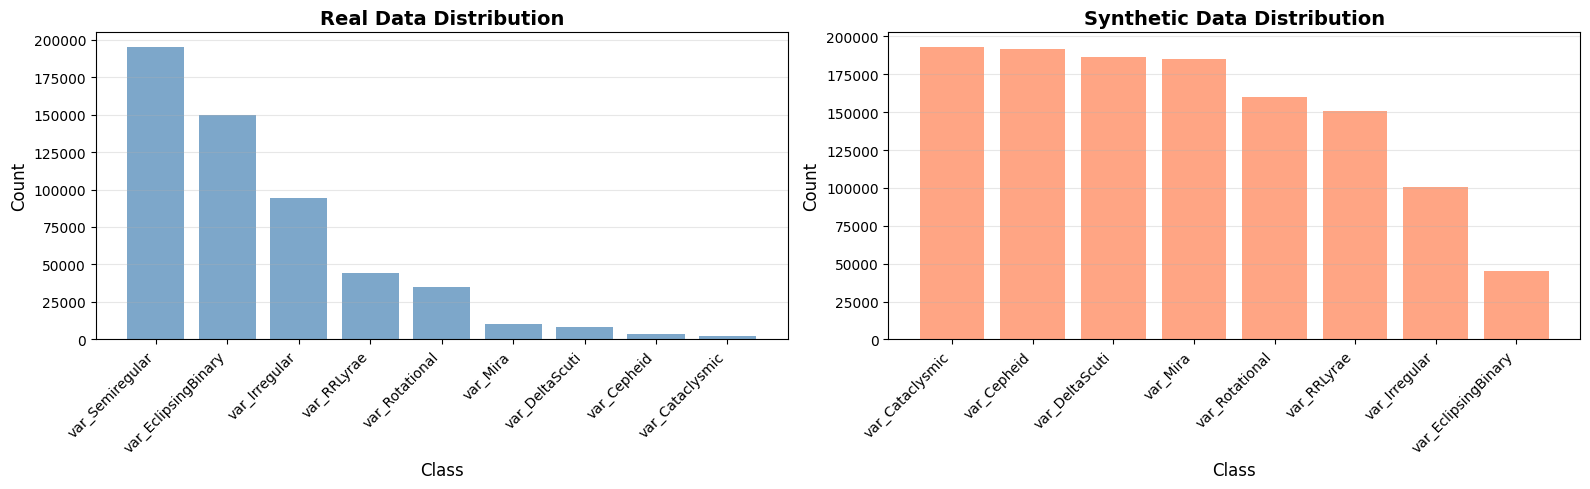

✓ Distribution comparison saved as 'data_distribution_comparison.png'


In [ ]:
# 4.6 Visualize: Class distribution
print("\n" + "="*60)
print("📈 VISUALIZING RESULTS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Real data distribution
real_labels = np.concatenate([loaded_data['y_train'], loaded_data['y_val']])
real_labels_decoded = label_encoder.inverse_transform(real_labels)
real_label_counts = pd.Series(real_labels_decoded).value_counts()

axes[0].bar(range(len(real_label_counts)), real_label_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Real Data Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(real_label_counts)))
axes[0].set_xticklabels(real_label_counts.index, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Synthetic data distribution
synthetic_label_counts = synthetic_df['label'].value_counts()

axes[1].bar(range(len(synthetic_label_counts)), synthetic_label_counts.values, color='coral', alpha=0.7)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Synthetic Data Distribution', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(synthetic_label_counts)))
axes[1].set_xticklabels(synthetic_label_counts.index, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution comparison saved as 'data_distribution_comparison.png'")


📐 Creating PCA visualization...


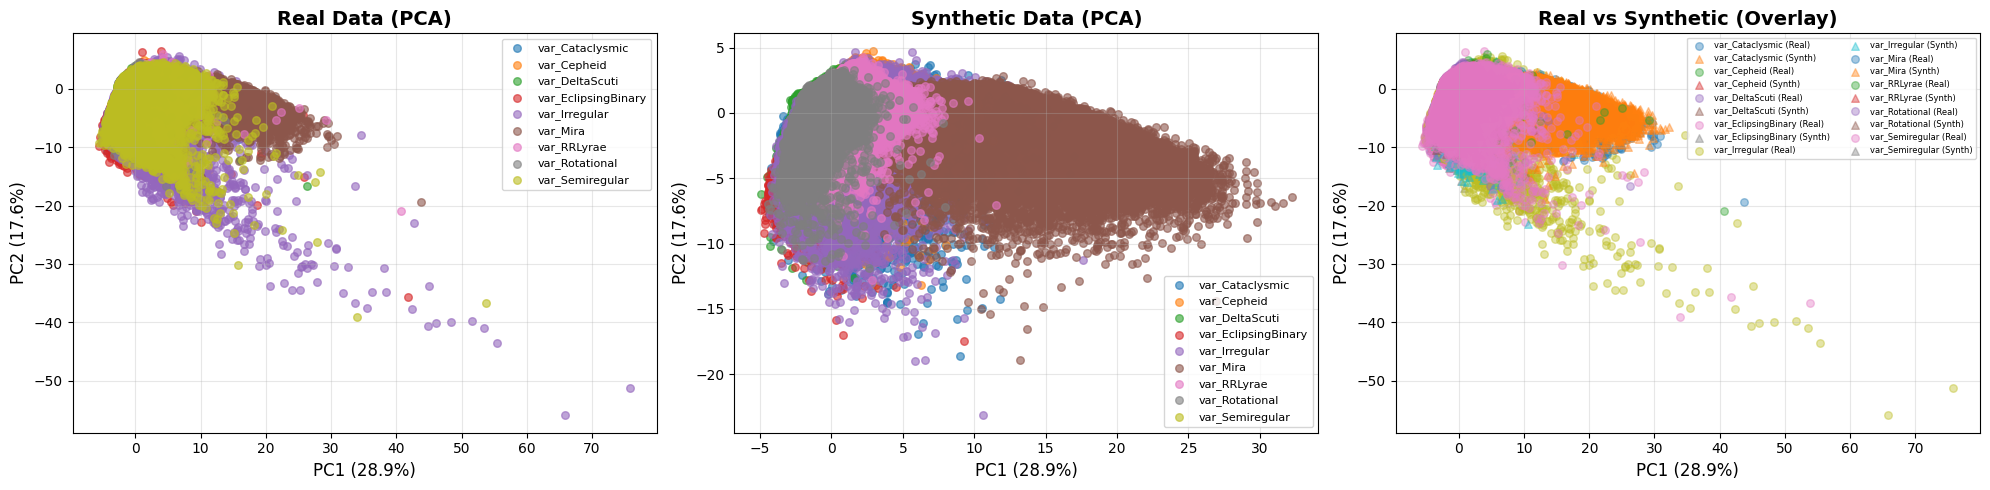

✓ PCA visualization saved as 'pca_visualization.png'


In [ ]:
# 4.7 Visualize: PCA projection
print("\n📐 Creating PCA visualization...")

# Combine real and synthetic data
real_features_scaled = np.vstack([loaded_data['X_train'], loaded_data['X_val']])

# Apply PCA
pca = PCA(n_components=2)
real_pca = pca.fit_transform(real_features_scaled)
synthetic_pca = pca.transform(synthetic_features_scaled)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Real data
for idx, class_name in enumerate(class_names):
    mask = real_labels == idx
    axes[0].scatter(real_pca[mask, 0], real_pca[mask, 1],
                   label=class_name, alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title('Real Data (PCA)', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Synthetic data
for idx, class_name in enumerate(class_names):
    mask = synthetic_labels_encoded == idx
    axes[1].scatter(synthetic_pca[mask, 0], synthetic_pca[mask, 1],
                   label=class_name, alpha=0.6, s=30)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].set_title('Synthetic Data (PCA)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

# Overlay
for idx, class_name in enumerate(class_names):
    real_mask = real_labels == idx
    synth_mask = synthetic_labels_encoded == idx
    axes[2].scatter(real_pca[real_mask, 0], real_pca[real_mask, 1],
                   label=f'{class_name} (Real)', alpha=0.4, s=30, marker='o')
    axes[2].scatter(synthetic_pca[synth_mask, 0], synthetic_pca[synth_mask, 1],
                   label=f'{class_name} (Synth)', alpha=0.4, s=30, marker='^')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[2].set_title('Real vs Synthetic (Overlay)', fontsize=14, fontweight='bold')
axes[2].legend(loc='best', fontsize=6, ncol=2)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ PCA visualization saved as 'pca_visualization.png'")

In [ ]:
# 4.8 Feature statistics comparison
print("\n" + "="*60)
print("📊 FEATURE STATISTICS COMPARISON")
print("="*60)

# Calculate statistics for each class
print("\nMean feature comparison (Real vs Synthetic):")
for class_idx, class_name in enumerate(class_names):
    if synthetic_counts[class_idx] > 0:
        print(f"\n{class_name}:")

        # Real data
        real_mask = real_labels == class_idx
        real_mean = real_features_scaled[real_mask].mean(axis=0)
        real_std = real_features_scaled[real_mask].std(axis=0)

        # Synthetic data
        synth_mask = synthetic_labels_encoded == class_idx
        synth_mean = synthetic_features_scaled[synth_mask].mean(axis=0)
        synth_std = synthetic_features_scaled[synth_mask].std(axis=0)

        # Calculate similarity
        mean_diff = np.abs(real_mean - synth_mean).mean()
        std_diff = np.abs(real_std - synth_std).mean()

        print(f"  Mean difference: {mean_diff:.4f}")
        print(f"  Std difference: {std_diff:.4f}")


📊 FEATURE STATISTICS COMPARISON

Mean feature comparison (Real vs Synthetic):

var_Cataclysmic:
  Mean difference: 0.1123
  Std difference: 0.2900

var_Cepheid:
  Mean difference: 0.0340
  Std difference: 0.2244

var_DeltaScuti:
  Mean difference: 0.0256
  Std difference: 0.2033

var_EclipsingBinary:
  Mean difference: 0.0104
  Std difference: 0.1789

var_Irregular:
  Mean difference: 0.0624
  Std difference: 0.4066

var_Mira:
  Mean difference: 0.0873
  Std difference: 0.2190

var_RRLyrae:
  Mean difference: 0.0221
  Std difference: 0.1697

var_Rotational:
  Mean difference: 0.0186
  Std difference: 0.2402


In [ ]:
# 4.9 Save synthetic data
print("\n" + "="*60)
print("💾 SAVING SYNTHETIC DATA")
print("="*60)

save_option = input("Save synthetic data? (y/n): ").strip().lower()

if save_option == 'y':
    filename = input("Enter filename (default: synthetic_data.csv): ").strip()
    if not filename:
        filename = "synthetic_data.csv"

    if not filename.endswith('.csv'):
        filename += '.csv'

    synthetic_df.to_csv("/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/" + filename, index=False)
    print(f"✓ Synthetic data saved as '{filename}'")


💾 SAVING SYNTHETIC DATA
Save synthetic data? (y/n): y
Enter filename (default: synthetic_data.csv): synthetic_data.csv
✓ Synthetic data saved as 'synthetic_data.csv'


In [ ]:
 # Also save combined data (real + synthetic)
save_combined = input("Save combined dataset (real + synthetic)? (y/n): ").strip().lower()
if save_combined == 'y':
    # Load original real data
    real_features = scaler.inverse_transform(real_features_scaled)
    real_df = pd.DataFrame(real_features, columns=feature_names)
    real_df['label'] = real_labels_decoded

    # Combine
    combined_df = pd.concat([real_df, synthetic_df], ignore_index=True)

    combined_filename = input("Enter filename for combined data (default: combined_data.csv): ").strip()
    if not combined_filename:
        combined_filename = "combined_data.csv"
    if not combined_filename.endswith('.csv'):
        combined_filename += '.csv'

    combined_df.to_csv("/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/" + combined_filename, index=False)
    print(f"✓ Combined data saved as '{combined_filename}'")
    print(f"  Total samples: {len(combined_df)} ({len(real_df)} real + {len(synthetic_df)} synthetic)")

Save combined dataset (real + synthetic)? (y/n): y
Enter filename for combined data (default: combined_data.csv): 
✓ Combined data saved as 'combined_data.csv'
  Total samples: 1755468 (543311 real + 1212157 synthetic)


## **Comparison**

In [ ]:
real_cVAE_df = pd.read_csv('/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/cleaned_25features_all.csv')
real_cVAE_df.head()

,PercentDifferenceFluxPercentile,Freq1_harmonics_amplitude_0,Meanvariance,PeriodLS_0,StetsonK_AC,Skew,Std,Amplitude,Rcs,Psi_eta_0,...,StetsonK,Autocor_length,FluxPercentileRatioMid50,AndersonDarling,FluxPercentileRatioMid65,Psi_CS_0,MedianAbsDev,Freq1_harmonics_amplitude_1,Beyond1Std,label
0,0.093965,0.306130,0.028682,297.456012,0.825241,-0.203652,0.478722,0.88550,0.088605,1.179267,...,0.797193,1.0,0.435587,0.85623,0.602041,0.204634,0.3440,0.120154,0.354680,var_Cataclysmic
1,0.122192,0.217150,0.036408,0.963788,0.760384,-1.177735,0.559093,1.12900,0.069157,1.872192,...,0.758991,1.0,0.316711,1.00000,0.471618,0.091739,0.2995,0.062729,0.364486,var_Cataclysmic
2,0.102245,0.177785,0.031158,0.491907,0.731720,-1.641033,0.532418,1.19825,0.074431,1.560145,...,0.719822,1.0,0.275014,1.00000,0.413951,0.131171,0.2370,0.142050,0.381166,var_Cataclysmic
3,0.075147,0.119638,0.027242,0.078062,0.729589,-3.261180,0.420262,0.66700,0.072364,1.819163,...,0.600220,1.0,0.235043,1.00000,0.552137,0.075280,0.1045,0.019772,0.332524,var_Cataclysmic
4,0.102542,0.295051,0.031667,176.849350,0.796719,-0.833826,0.546931,0.98250,0.076650,1.064748,...,0.732743,1.0,0.427370,1.00000,0.559731,0.175268,0.3590,0.162672,0.482143,var_Cataclysmic


In [ ]:
real_cVAE_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543311 entries, 0 to 543310
Data columns (total 26 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   PercentDifferenceFluxPercentile  543311 non-null  float64
 1   Freq1_harmonics_amplitude_0      543311 non-null  float64
 2   Meanvariance                     543311 non-null  float64
 3   PeriodLS_0                       543311 non-null  float64
 4   StetsonK_AC                      543311 non-null  float64
 5   Skew                             543311 non-null  float64
 6   Std                              543311 non-null  float64
 7   Amplitude                        543311 non-null  float64
 8   Rcs                              543311 non-null  float64
 9   Psi_eta_0                        543311 non-null  float64
 10  Mean                             543311 non-null  float64
 11  CAR_mean                         543311 non-null  float64
 12  Gs

In [ ]:
combined_cVAE_df = pd.read_csv("/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/combined_data.csv")
combined_cVAE_df.head()

,PercentDifferenceFluxPercentile,Freq1_harmonics_amplitude_0,Meanvariance,PeriodLS_0,StetsonK_AC,Skew,Std,Amplitude,Rcs,Psi_eta_0,...,StetsonK,Autocor_length,FluxPercentileRatioMid50,AndersonDarling,FluxPercentileRatioMid65,Psi_CS_0,MedianAbsDev,Freq1_harmonics_amplitude_1,Beyond1Std,label
0,0.026348,0.120040,0.008713,0.156144,0.735017,-0.627900,0.126061,0.21750,0.069955,0.907102,...,0.841019,1.0,0.515707,1.000000,0.625654,0.194473,0.0885,0.045469,0.384146,var_DeltaScuti
1,0.076233,0.342204,0.021548,197.542094,0.891634,0.582279,0.312828,0.63850,0.042955,0.409201,...,0.821440,1.0,0.369565,1.000000,0.511775,0.313852,0.1970,0.133556,0.264117,var_Semiregular
2,0.004534,0.623437,0.001895,16786.190600,0.679658,2.827498,0.022990,0.04000,0.120991,1.347165,...,0.656915,1.0,0.400000,1.000000,0.600000,0.192955,0.0110,0.159957,0.178322,var_Irregular
3,0.075626,0.299551,0.022270,108.012816,0.856915,-0.014738,0.294648,0.59800,0.100275,0.864966,...,0.788010,1.0,0.362000,0.741111,0.621000,0.241689,0.1810,0.086292,0.360000,var_Semiregular
4,0.029490,0.152402,0.009466,265.362443,0.905854,-0.724413,0.141103,0.24575,0.085213,0.387118,...,0.836512,1.0,0.451247,1.000000,0.653061,0.362741,0.0745,0.095687,0.350000,var_Semiregular


In [ ]:
combined_cVAE_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755468 entries, 0 to 1755467
Data columns (total 26 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   PercentDifferenceFluxPercentile  float64
 1   Freq1_harmonics_amplitude_0      float64
 2   Meanvariance                     float64
 3   PeriodLS_0                       float64
 4   StetsonK_AC                      float64
 5   Skew                             float64
 6   Std                              float64
 7   Amplitude                        float64
 8   Rcs                              float64
 9   Psi_eta_0                        float64
 10  Mean                             float64
 11  CAR_mean                         float64
 12  Gskew                            float64
 13  Q31                              float64
 14  SlottedA_length                  float64
 15  PercentAmplitude                 float64
 16  StetsonK                         float64
 17  Autocor_

In [ ]:
# ============================================================================
# STEP 1: Configure your target column name here
# ============================================================================
TARGET_COLUMN = 'label'

# ============================================================================
# STEP 2: Prepare your data
# ============================================================================

# Your dataframe is already loaded:
real_cVAE_df = pd.read_csv('/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/cleaned_25features_all.csv')

# Separate features and target
y = real_cVAE_df[TARGET_COLUMN].values
X = real_cVAE_df.drop(columns=[TARGET_COLUMN]).values

# Get number of classes
n_classes = len(np.unique(y))

# Encode labels if they are strings
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print(f"Classes encoded: {le.classes_}")

print(f"Data shape: {X.shape}")
print(f"Number of classes: {n_classes}")
print(f"Class distribution: {np.bincount(y)}")

# ============================================================================
# STEP 3: XGBoost Parameters (as specified)
# ============================================================================

params = {
    'objective': 'multi:softmax',
    'num_class': n_classes,
    'max_depth': 4,              # Maximum tree depth = 4
    'learning_rate': 0.1,        # Learning rate = 0.1
    'eval_metric': 'merror',
    'seed': 42
}

# ============================================================================
# STEP 4: 10-Fold Cross-Validation with Early Stopping
# ============================================================================

# Initialize 10-fold stratified cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store accuracies and times for each fold
accuracies = []
fold_times = []

print("\n" + "="*60)
print("10-Fold Cross-Validation Results")
print("="*60)

# Start total training time
total_start_time = time.time()

# Perform cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    fold_start_time = time.time()
    # Split data
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Create DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    # Training with early stopping (stop if no improvement for 10 iterations)
    evals = [(dtrain, 'train'), (dval, 'val')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=10,  # Early stopping = 10 iterations
        verbose_eval=False
    )

    # Predict and calculate accuracy
    y_pred = model.predict(dval)
    accuracy = accuracy_score(y_val, y_pred)
    accuracies.append(accuracy)

    # Calculate fold training time
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)

    print(f"Fold {fold:2d}: Accuracy = {accuracy:.4f} | Time = {fold_time:.2f}s (stopped at iteration {model.best_iteration})")

# Calculate total training time
total_time = time.time() - total_start_time

# ============================================================================
# STEP 5: Calculate and Report Results
# ============================================================================

mean_accuracy = np.mean(accuracies)
std_deviation = np.std(accuracies, ddof=1)
std_error = std_deviation / np.sqrt(10)
mean_fold_time = np.mean(fold_times)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Average Accuracy:        {mean_accuracy:.4f}")
print(f"Standard Deviation:      {std_deviation:.4f}")
print(f"Standard Error:          {std_error:.4f}")
print(f"95% CI:                  [{mean_accuracy - 1.96*std_error:.4f}, {mean_accuracy + 1.96*std_error:.4f}]")
print(f"\nTraining Time:")
print(f"  Total time:            {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print(f"  Average per fold:      {mean_fold_time:.2f} seconds")
print(f"  Min fold time:         {min(fold_times):.2f} seconds")
print(f"  Max fold time:         {max(fold_times):.2f} seconds")
print("="*60)

# Store results in a dictionary for easy access
results = {
    'mean_accuracy': mean_accuracy,
    'std_error': std_error,
    'std_deviation': std_deviation,
    'all_accuracies': accuracies,
    'total_training_time': total_time,
    'mean_fold_time': mean_fold_time,
    'all_fold_times': fold_times
}

print(f"\nAll fold accuracies: {[f'{acc:.4f}' for acc in accuracies]}")

Classes encoded: ['var_Cataclysmic' 'var_Cepheid' 'var_DeltaScuti' 'var_EclipsingBinary'
 'var_Irregular' 'var_Mira' 'var_RRLyrae' 'var_Rotational'
 'var_Semiregular']
Data shape: (543311, 25)
Number of classes: 9
Class distribution: [  2053   3696   8537 149910  94543  10230  44286  35004 195052]

10-Fold Cross-Validation Results
Fold  1: Accuracy = 0.8139 | Time = 191.87s (stopped at iteration 352)
Fold  2: Accuracy = 0.8162 | Time = 178.64s (stopped at iteration 342)
Fold  3: Accuracy = 0.8141 | Time = 170.74s (stopped at iteration 326)
Fold  4: Accuracy = 0.8122 | Time = 113.38s (stopped at iteration 204)
Fold  5: Accuracy = 0.8144 | Time = 156.89s (stopped at iteration 299)
Fold  6: Accuracy = 0.8095 | Time = 105.23s (stopped at iteration 190)
Fold  7: Accuracy = 0.8133 | Time = 130.96s (stopped at iteration 245)
Fold  8: Accuracy = 0.8176 | Time = 196.00s (stopped at iteration 380)
Fold  9: Accuracy = 0.8156 | Time = 160.66s (stopped at iteration 303)
Fold 10: Accuracy = 0.8154 |

In [ ]:
# @title
# ============================================================================
# STEP 1: Configure your target column name here
# ============================================================================
TARGET_COLUMN = 'label'

# ============================================================================
# STEP 2: Prepare your data
# ============================================================================

# Your dataframe is already loaded:
combined_cVAE_df = pd.read_csv("/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/combined_data.csv")

# Separate features and target
y = combined_cVAE_df[TARGET_COLUMN].values
X = combined_cVAE_df.drop(columns=[TARGET_COLUMN]).values

# Get number of classes
n_classes = len(np.unique(y))

# Encode labels if they are strings
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print(f"Classes encoded: {le.classes_}")

print(f"Data shape: {X.shape}")
print(f"Number of classes: {n_classes}")
print(f"Class distribution: {np.bincount(y)}")

# ============================================================================
# STEP 3: XGBoost Parameters (as specified)
# ============================================================================

params = {
    'objective': 'multi:softmax',
    'num_class': n_classes,
    'max_depth': 4,              # Maximum tree depth = 4
    'learning_rate': 0.1,        # Learning rate = 0.1
    'eval_metric': 'merror',
    'seed': 42
}

# ============================================================================
# STEP 4: 10-Fold Cross-Validation with Early Stopping
# ============================================================================

# Initialize 10-fold stratified cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store accuracies and times for each fold
accuracies = []
fold_times = []

print("\n" + "="*60)
print("10-Fold Cross-Validation Results")
print("="*60)

# Start total training time
total_start_time = time.time()

# Perform cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    fold_start_time = time.time()
    # Split data
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Create DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    # Training with early stopping (stop if no improvement for 10 iterations)
    evals = [(dtrain, 'train'), (dval, 'val')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=10,  # Early stopping = 10 iterations
        verbose_eval=False
    )

    # Predict and calculate accuracy
    y_pred = model.predict(dval)
    accuracy = accuracy_score(y_val, y_pred)
    accuracies.append(accuracy)

    # Calculate fold training time
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)

    print(f"Fold {fold:2d}: Accuracy = {accuracy:.4f} | Time = {fold_time:.2f}s (stopped at iteration {model.best_iteration})")

# Calculate total training time
total_time = time.time() - total_start_time

# ============================================================================
# STEP 5: Calculate and Report Results
# ============================================================================

mean_accuracy = np.mean(accuracies)
std_deviation = np.std(accuracies, ddof=1)
std_error = std_deviation / np.sqrt(10)
mean_fold_time = np.mean(fold_times)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Average Accuracy:        {mean_accuracy:.4f}")
print(f"Standard Deviation:      {std_deviation:.4f}")
print(f"Standard Error:          {std_error:.4f}")
print(f"95% CI:                  [{mean_accuracy - 1.96*std_error:.4f}, {mean_accuracy + 1.96*std_error:.4f}]")
print(f"\nTraining Time:")
print(f"  Total time:            {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print(f"  Average per fold:      {mean_fold_time:.2f} seconds")
print(f"  Min fold time:         {min(fold_times):.2f} seconds")
print(f"  Max fold time:         {max(fold_times):.2f} seconds")
print("="*60)

# Store results in a dictionary for easy access
results = {
    'mean_accuracy': mean_accuracy,
    'std_error': std_error,
    'std_deviation': std_deviation,
    'all_accuracies': accuracies,
    'total_training_time': total_time,
    'mean_fold_time': mean_fold_time,
    'all_fold_times': fold_times
}

print(f"\nAll fold accuracies: {[f'{acc:.4f}' for acc in accuracies]}")

In [ ]:
# real_cVAE_df = pd.read_csv('/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/cleaned_25features_all.csv')
# syn_cVAE_df = pd.read_csv("/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/synthetic_data.csv")

In [ ]:
# @title
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
TARGET_COLUMN = 'label'  # Change to your target column name
TEST_SIZE = 0.2  # 20% of real data for testing
RANDOM_STATE = 42
N_FOLDS = 10

# ============================================================================
# XGBoost Parameters
# ============================================================================
XGBOOST_PARAMS = {
    'max_depth': 4,
    'learning_rate': 0.1,
    'early_stopping_rounds': 10,
    'num_boost_round': 1000
}

print("="*80)
print("XGBoost Evaluation: Real vs Real+Synthetic Data")
print("="*80)
print(f"Configuration:")
print(f"  - Test size: {TEST_SIZE*100}% of real data")
print(f"  - Cross-validation folds: {N_FOLDS}")
print(f"  - XGBoost max_depth: {XGBOOST_PARAMS['max_depth']}")
print(f"  - XGBoost learning_rate: {XGBOOST_PARAMS['learning_rate']}")
print(f"  - Early stopping rounds: {XGBOOST_PARAMS['early_stopping_rounds']}")
print("="*80)

# ============================================================================
# Load Data
# ============================================================================
print("\n📂 Loading datasets...")

# Load your datasets
real_cVAE_df = pd.read_csv('/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/cleaned_25features_all.csv')
syn_cVAE_df = pd.read_csv("/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/synthetic_data.csv")

print(f"✓ Real data shape: {real_cVAE_df.shape}")
print(f"✓ Synthetic data shape: {syn_cVAE_df.shape}")

# ============================================================================
# Data Preparation
# ============================================================================

def prepare_data(df, target_col):
    """Extract features and target"""
    y = df[target_col].copy()
    X = df.drop(columns=[target_col])

    # Encode labels if needed
    label_encoder = None
    if y.dtype == 'object':
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(y)

    return X.values, y, label_encoder

# Prepare real data
X_real, y_real, label_encoder = prepare_data(real_cVAE_df, TARGET_COLUMN)

# Prepare synthetic data
X_syn, y_syn, _ = prepare_data(syn_cVAE_df, TARGET_COLUMN)

# Get class information
n_classes = len(np.unique(y_real))
class_names = label_encoder.classes_ if label_encoder else [str(i) for i in range(n_classes)]

print(f"\n📊 Dataset Statistics:")
print(f"  Number of classes: {n_classes}")
print(f"  Total real samples: {len(y_real):,}")
print(f"  Total synthetic samples: {len(y_syn):,}")

print(f"\n📋 Class Distribution in Real Data:")
for i, class_name in enumerate(class_names):
    count = np.sum(y_real == i)
    print(f"  {i}: {class_name:30s} → {count:7,} samples ({count/len(y_real)*100:5.2f}%)")

print(f"\n📋 Class Distribution in Synthetic Data:")
for i, class_name in enumerate(class_names):
    count = np.sum(y_syn == i)
    print(f"  {i}: {class_name:30s} → {count:7,} samples ({count/len(y_syn)*100:5.2f}%)")


# ============================================================================
# 10-Fold Cross-Validation
# ============================================================================

def evaluate_cross_validation(X_real, y_real, X_syn, y_syn, n_folds=10):
    """
    Evaluate using stratified k-fold cross-validation
    Each fold: train on (real_train_fold + ALL synthetic), test on real_val_fold
    """
    print("\n" + "="*80)
    print(f"{n_folds}-Fold Cross-Validation")
    print("="*80)

    params = {
        'objective': 'multi:softmax',
        'num_class': n_classes,
        'max_depth': XGBOOST_PARAMS['max_depth'],
        'learning_rate': XGBOOST_PARAMS['learning_rate'],
        'eval_metric': 'merror',
        'seed': RANDOM_STATE
    }

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    # Storage for results
    baseline_results = {'accuracies': [], 'precisions': [], 'recalls': [], 'f1s': [], 'times': []}
    augmented_results = {'accuracies': [], 'precisions': [], 'recalls': [], 'f1s': [], 'times': []}

    print("\n" + "-"*80)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_real, y_real), 1):
        print(f"\n{'='*80}")
        print(f"Fold {fold}/{n_folds}")
        print(f"{'='*80}")

        # Split real data
        X_real_train, X_real_val = X_real[train_idx], X_real[val_idx]
        y_real_train, y_real_val = y_real[train_idx], y_real[val_idx]

        dval = xgb.DMatrix(X_real_val, label=y_real_val)

        # ====================================================================
        # BASELINE: Real only
        # ====================================================================
        print(f"\n🔵 Baseline (Real only): {X_real_train.shape[0]:,} samples")

        dtrain_real = xgb.DMatrix(X_real_train, label=y_real_train)

        start_time = time.time()
        model_real = xgb.train(
            params,
            dtrain_real,
            num_boost_round=XGBOOST_PARAMS['num_boost_round'],
            evals=[(dtrain_real, 'train'), (dval, 'val')],
            early_stopping_rounds=XGBOOST_PARAMS['early_stopping_rounds'],
            verbose_eval=False
        )
        time_real = time.time() - start_time

        y_pred_real = model_real.predict(dval)
        acc_real = accuracy_score(y_real_val, y_pred_real)
        prec_real, rec_real, f1_real, _ = precision_recall_fscore_support(
            y_real_val, y_pred_real, average='weighted', zero_division=0
        )

        baseline_results['accuracies'].append(acc_real)
        baseline_results['precisions'].append(prec_real)
        baseline_results['recalls'].append(rec_real)
        baseline_results['f1s'].append(f1_real)
        baseline_results['times'].append(time_real)

        print(f"  Accuracy: {acc_real:.4f} | Time: {time_real:.2f}s")

        # ====================================================================
        # AUGMENTED: Real + Synthetic
        # ====================================================================
        X_combined = np.vstack([X_real_train, X_syn])
        y_combined = np.concatenate([y_real_train, y_syn])

        print(f"\n🟢 Augmented (Real+Synthetic): {X_combined.shape[0]:,} samples")

        dtrain_combined = xgb.DMatrix(X_combined, label=y_combined)

        start_time = time.time()
        model_combined = xgb.train(
            params,
            dtrain_combined,
            num_boost_round=XGBOOST_PARAMS['num_boost_round'],
            evals=[(dtrain_combined, 'train'), (dval, 'val')],
            early_stopping_rounds=XGBOOST_PARAMS['early_stopping_rounds'],
            verbose_eval=False
        )
        time_combined = time.time() - start_time

        y_pred_combined = model_combined.predict(dval)
        acc_combined = accuracy_score(y_real_val, y_pred_combined)
        prec_combined, rec_combined, f1_combined, _ = precision_recall_fscore_support(
            y_real_val, y_pred_combined, average='weighted', zero_division=0
        )

        augmented_results['accuracies'].append(acc_combined)
        augmented_results['precisions'].append(prec_combined)
        augmented_results['recalls'].append(rec_combined)
        augmented_results['f1s'].append(f1_combined)
        augmented_results['times'].append(time_combined)

        print(f"  Accuracy: {acc_combined:.4f} | Time: {time_combined:.2f}s")
        print(f"  Improvement: {(acc_combined - acc_real)*100:+.2f}%")

    # ========================================================================
    # Summarize Cross-Validation Results
    # ========================================================================
    print("\n" + "="*80)
    print(f"📊 CROSS-VALIDATION SUMMARY ({n_folds} folds)")
    print("="*80)

    def print_stats(metric_name, baseline_vals, augmented_vals):
        baseline_mean = np.mean(baseline_vals)
        baseline_std = np.std(baseline_vals, ddof=1)
        baseline_se = baseline_std / np.sqrt(len(baseline_vals))

        augmented_mean = np.mean(augmented_vals)
        augmented_std = np.std(augmented_vals, ddof=1)
        augmented_se = augmented_std / np.sqrt(len(augmented_vals))

        improvement = (augmented_mean - baseline_mean) * 100

        print(f"\n{metric_name}:")
        print(f"  Baseline:   {baseline_mean:.4f} ± {baseline_se:.4f} (SE)")
        print(f"  Augmented:  {augmented_mean:.4f} ± {augmented_se:.4f} (SE)")
        print(f"  Improvement: {improvement:+.2f}%")

        return baseline_mean, augmented_mean, baseline_se, augmented_se

    acc_base, acc_aug, acc_base_se, acc_aug_se = print_stats(
        "Accuracy", baseline_results['accuracies'], augmented_results['accuracies']
    )

    print_stats("Precision", baseline_results['precisions'], augmented_results['precisions'])
    print_stats("Recall", baseline_results['recalls'], augmented_results['recalls'])

    f1_base, f1_aug, f1_base_se, f1_aug_se = print_stats(
        "F1-Score", baseline_results['f1s'], augmented_results['f1s']
    )

    print(f"\nTraining Time:")
    print(f"  Baseline:   {np.mean(baseline_results['times']):.2f} ± {np.std(baseline_results['times'], ddof=1):.2f}s")
    print(f"  Augmented:  {np.mean(augmented_results['times']):.2f} ± {np.std(augmented_results['times'], ddof=1):.2f}s")

    # Statistical significance (simple comparison)
    acc_improvement = (acc_aug - acc_base) * 100
    f1_improvement = (f1_aug - f1_base) * 100

    print("\n" + "="*80)
    print("🎯 FINAL VERDICT")
    print("="*80)

    if acc_improvement > 0.5:  # Improvement > 0.5%
        print(f"✅ Synthetic data SIGNIFICANTLY IMPROVED model performance")
        print(f"   • Accuracy improved by {acc_improvement:.2f}%")
        print(f"   • F1-Score improved by {f1_improvement:.2f}%")
    elif acc_improvement > 0:
        print(f"✔️  Synthetic data SLIGHTLY IMPROVED model performance")
        print(f"   • Accuracy improved by {acc_improvement:.2f}%")
    elif acc_improvement < -0.5:
        print(f"❌ Synthetic data DECREASED model performance")
        print(f"   • Accuracy decreased by {abs(acc_improvement):.2f}%")
        print(f"   • Consider improving synthetic data quality")
    else:
        print(f"➖ Synthetic data had MINIMAL IMPACT on performance")
        print(f"   • Accuracy change: {acc_improvement:+.2f}%")

    return {
        'baseline': baseline_results,
        'augmented': augmented_results,
        'summary': {
            'accuracy_baseline': acc_base,
            'accuracy_augmented': acc_aug,
            'accuracy_improvement': acc_improvement,
            'f1_baseline': f1_base,
            'f1_augmented': f1_aug,
            'f1_improvement': f1_improvement
        }
    }

# ============================================================================
# Run Evaluations
# ============================================================================

print("\n" + "="*80)
print("🚀 Starting Evaluation")
print("="*80)

# Cross-validation
cv_results = evaluate_cross_validation(X_real, y_real, X_syn, y_syn, n_folds=N_FOLDS)

print("\n" + "="*80)
print("✅ Evaluation Complete!")
print("="*80)
print("\nBoth evaluation methods completed successfully.")
print("Results are stored in 'split_results' and 'cv_results' variables.")

XGBoost Evaluation: Real vs Real+Synthetic Data
Configuration:
  - Cross-validation folds: 10
  - XGBoost max_depth: 4
  - XGBoost learning_rate: 0.1
  - Early stopping rounds: 10

📂 Loading datasets...
✓ Real data shape: (543311, 26)
✓ Synthetic data shape: (1212157, 26)

📊 Dataset Statistics:
  Number of classes: 9
  Total real samples: 543,311
  Total synthetic samples: 1,212,157

📋 Class Distribution in Real Data:
  0: var_Cataclysmic                →   2,053 samples ( 0.38%)
  1: var_Cepheid                    →   3,696 samples ( 0.68%)
  2: var_DeltaScuti                 →   8,537 samples ( 1.57%)
  3: var_EclipsingBinary            → 149,910 samples (27.59%)
  4: var_Irregular                  →  94,543 samples (17.40%)
  5: var_Mira                       →  10,230 samples ( 1.88%)
  6: var_RRLyrae                    →  44,286 samples ( 8.15%)
  7: var_Rotational                 →  35,004 samples ( 6.44%)
  8: var_Semiregular                → 195,052 samples (35.90%)

📋 Class Di

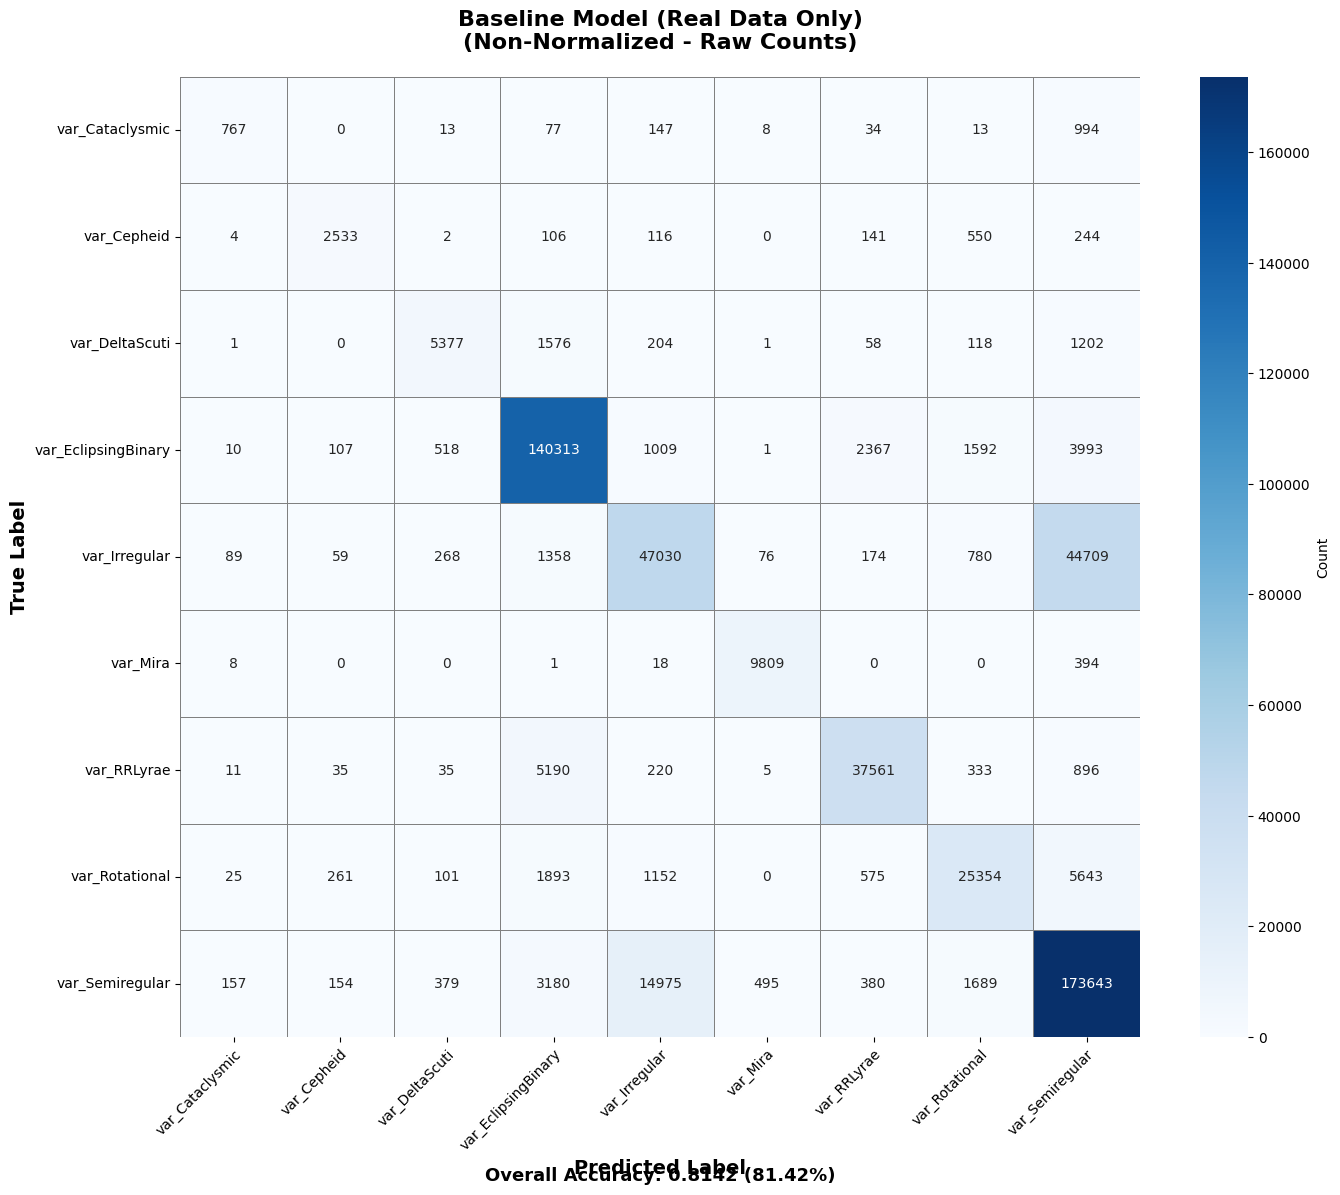


🔵 Baseline (Real Only) - Normalized:
  ✓ Saved: cm_baseline_normalized.png


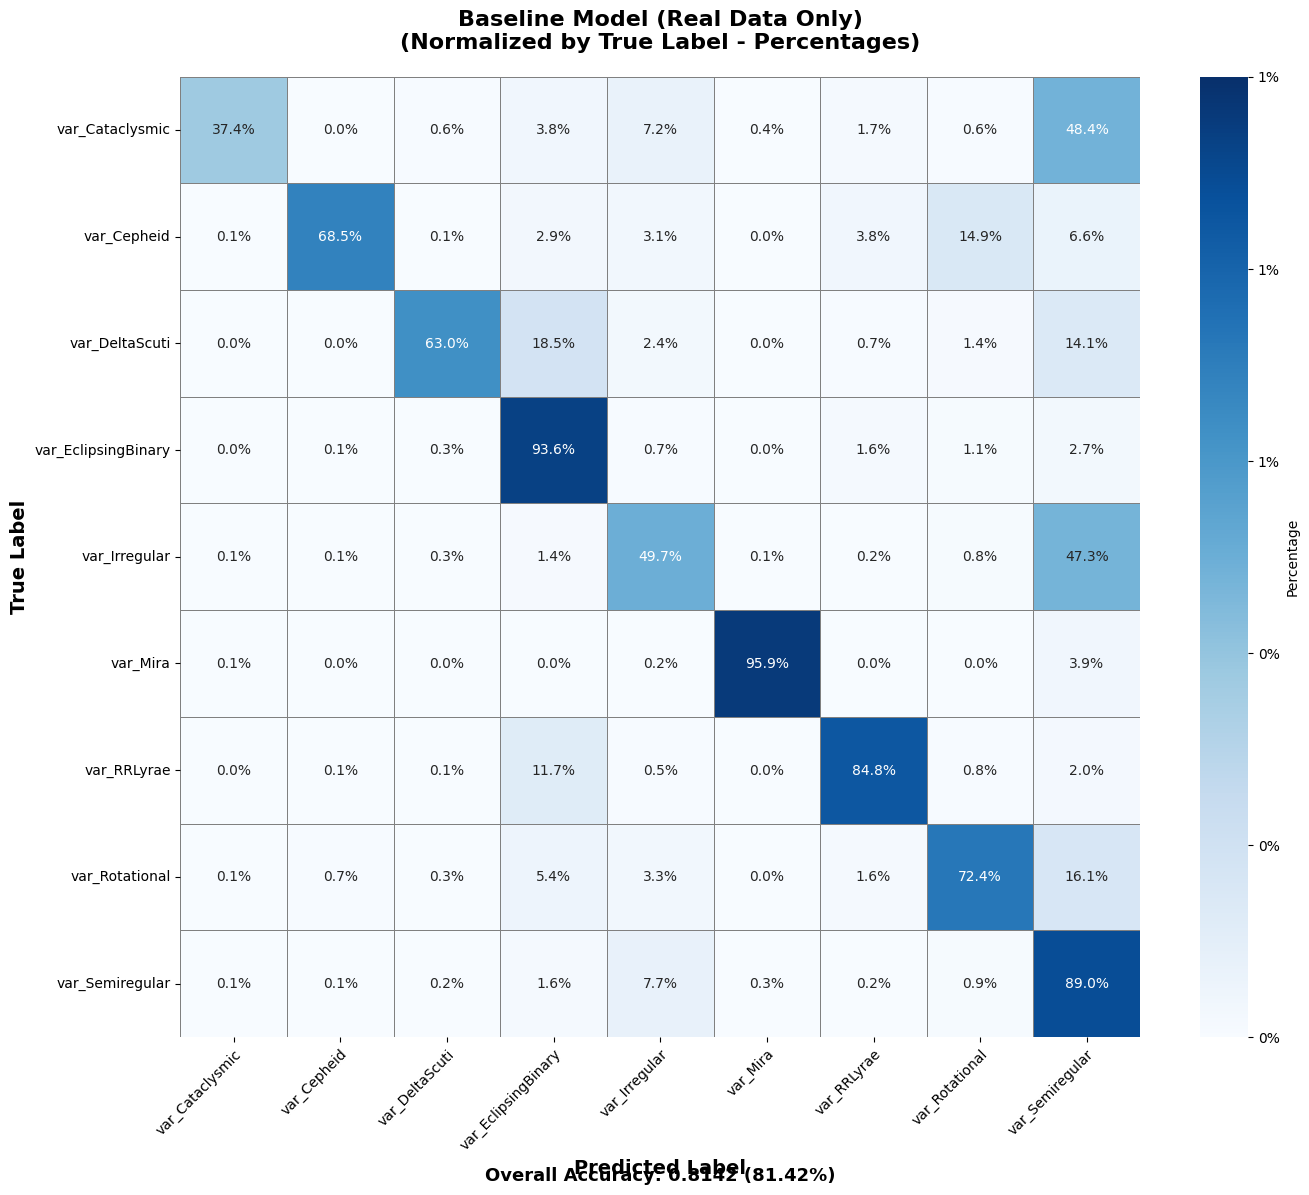


🟢 Augmented (Real+Synthetic) - Non-Normalized:
  ✓ Saved: cm_augmented_raw.png


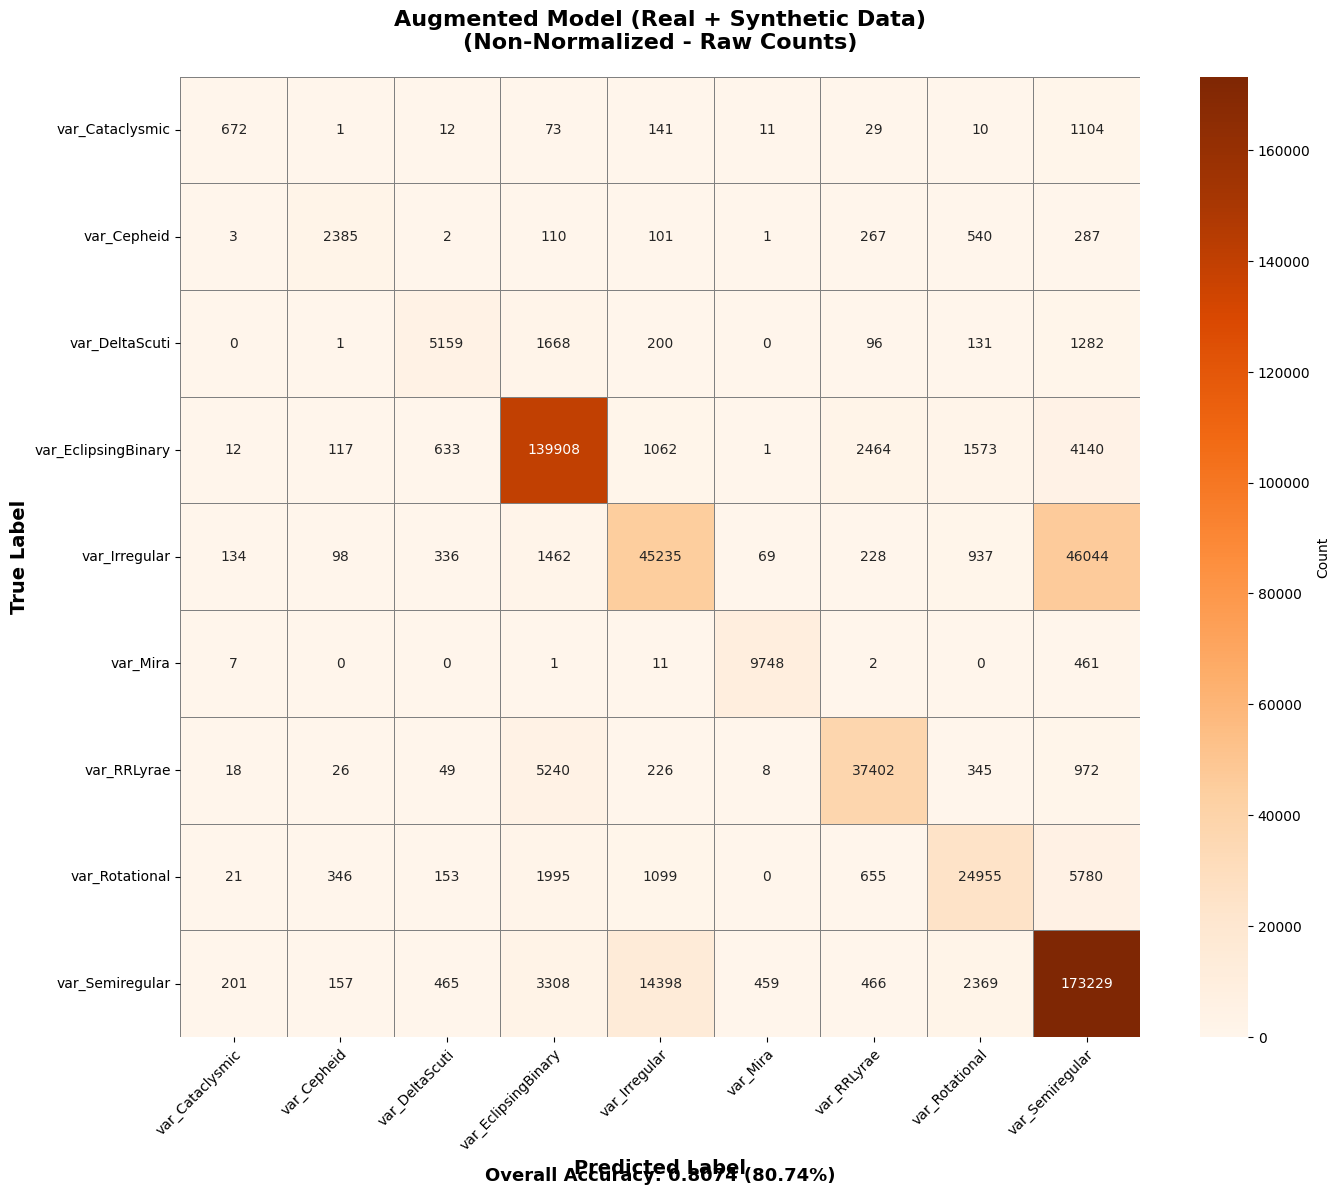


🟢 Augmented (Real+Synthetic) - Normalized:
  ✓ Saved: cm_augmented_normalized.png


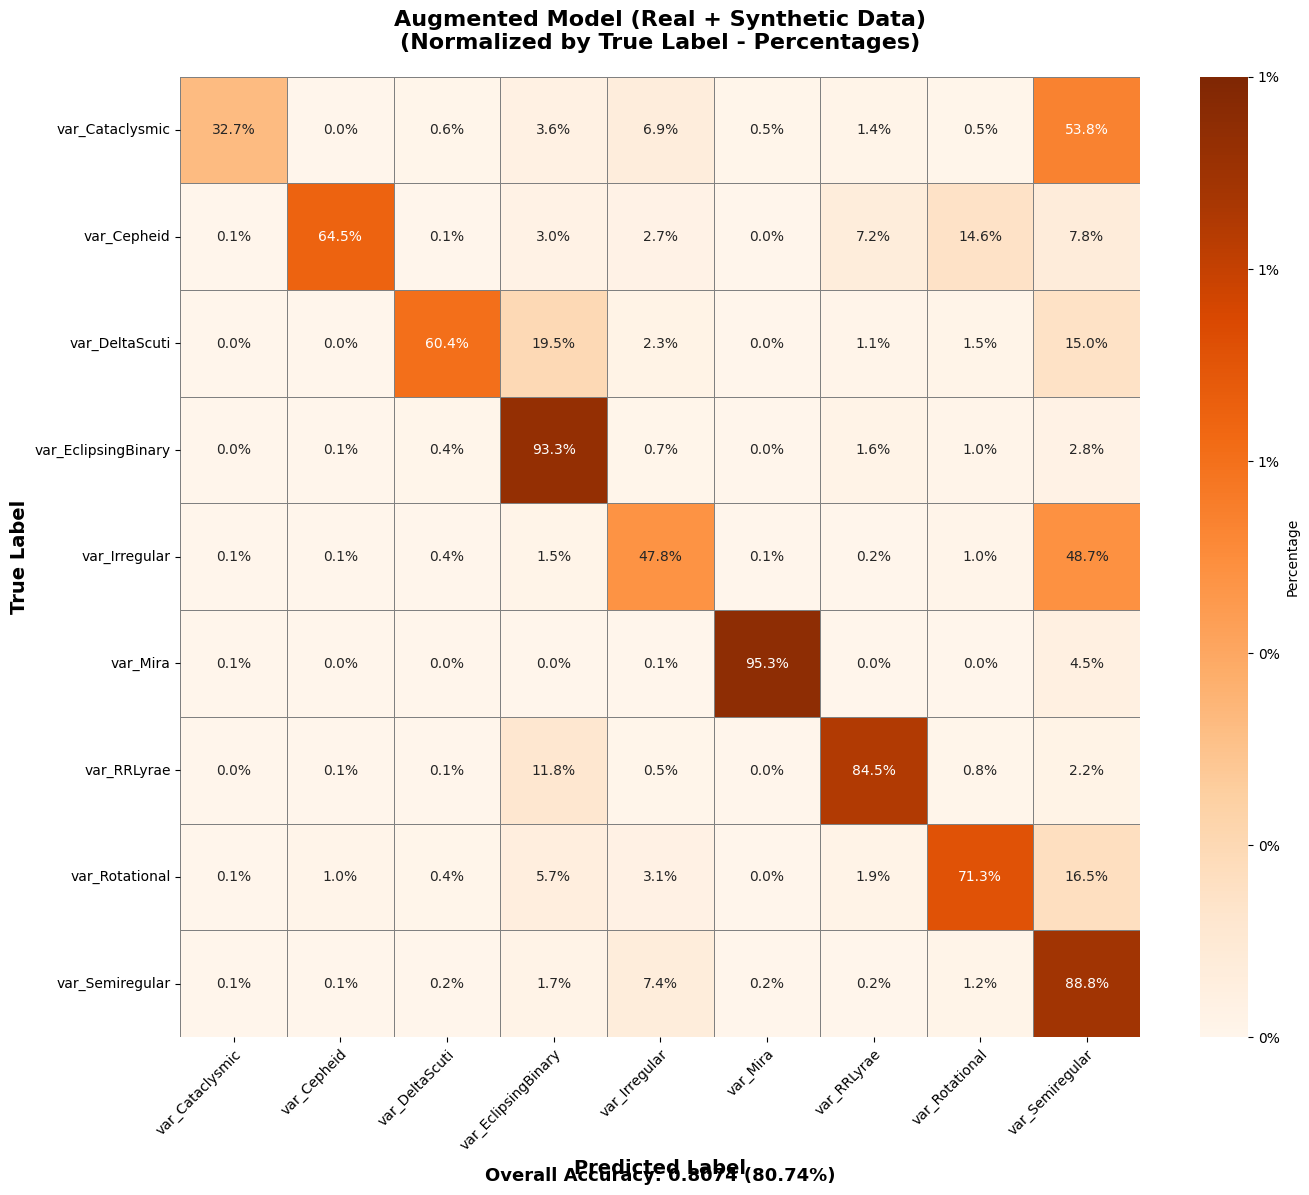


✅ All confusion matrices generated!

✅ All Evaluations Complete!

Results stored in 'cv_results' variable.
Confusion matrix images saved to current directory.


In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================
TARGET_COLUMN = 'label'
RANDOM_STATE = 42
N_FOLDS = 10

XGBOOST_PARAMS = {
    'max_depth': 4,
    'learning_rate': 0.1,
    'early_stopping_rounds': 10,
    'num_boost_round': 1000
}

print("="*80)
print("XGBoost Evaluation: Real vs Real+Synthetic Data")
print("="*80)
print(f"Configuration:")
print(f"  - Cross-validation folds: {N_FOLDS}")
print(f"  - XGBoost max_depth: {XGBOOST_PARAMS['max_depth']}")
print(f"  - XGBoost learning_rate: {XGBOOST_PARAMS['learning_rate']}")
print(f"  - Early stopping rounds: {XGBOOST_PARAMS['early_stopping_rounds']}")
print("="*80)

# ============================================================================
# Load Data
# ============================================================================
print("\n📂 Loading datasets...")

real_cVAE_df = pd.read_csv('/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/cleaned_25features_all.csv')
syn_cVAE_df = pd.read_csv("/content/drive/MyDrive/NARIT/Project2_Syntheticdata/Dataset/synthetic_data.csv")

print(f"✓ Real data shape: {real_cVAE_df.shape}")
print(f"✓ Synthetic data shape: {syn_cVAE_df.shape}")

# ============================================================================
# Data Preparation
# ============================================================================

def prepare_data(df, target_col):
    """Extract features and target"""
    y = df[target_col].copy()
    X = df.drop(columns=[target_col])

    label_encoder = None
    if y.dtype == 'object':
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(y)

    return X.values, y, label_encoder

X_real, y_real, label_encoder = prepare_data(real_cVAE_df, TARGET_COLUMN)
X_syn, y_syn, _ = prepare_data(syn_cVAE_df, TARGET_COLUMN)

n_classes = len(np.unique(y_real))
class_names = label_encoder.classes_ if label_encoder else [str(i) for i in range(n_classes)]

print(f"\n📊 Dataset Statistics:")
print(f"  Number of classes: {n_classes}")
print(f"  Total real samples: {len(y_real):,}")
print(f"  Total synthetic samples: {len(y_syn):,}")

print(f"\n📋 Class Distribution in Real Data:")
for i, class_name in enumerate(class_names):
    count = np.sum(y_real == i)
    print(f"  {i}: {class_name:30s} → {count:7,} samples ({count/len(y_real)*100:5.2f}%)")

print(f"\n📋 Class Distribution in Synthetic Data:")
for i, class_name in enumerate(class_names):
    count = np.sum(y_syn == i)
    print(f"  {i}: {class_name:30s} → {count:7,} samples ({count/len(y_syn)*100:5.2f}%)")

# ============================================================================
# 10-Fold Cross-Validation (Modified to collect predictions)
# ============================================================================

def evaluate_cross_validation(X_real, y_real, X_syn, y_syn, n_folds=10):
    """
    Evaluate using stratified k-fold cross-validation
    Collects all predictions for confusion matrix visualization
    """
    print("\n" + "="*80)
    print(f"{n_folds}-Fold Cross-Validation")
    print("="*80)

    params = {
        'objective': 'multi:softmax',
        'num_class': n_classes,
        'max_depth': XGBOOST_PARAMS['max_depth'],
        'learning_rate': XGBOOST_PARAMS['learning_rate'],
        'eval_metric': 'merror',
        'seed': RANDOM_STATE
    }

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    # Storage for metrics
    baseline_results = {'accuracies': [], 'precisions': [], 'recalls': [], 'f1s': [], 'times': []}
    augmented_results = {'accuracies': [], 'precisions': [], 'recalls': [], 'f1s': [], 'times': []}

    # Storage for predictions (for confusion matrix)
    baseline_all_predictions = []
    baseline_all_true = []
    augmented_all_predictions = []
    augmented_all_true = []

    print("\n" + "-"*80)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_real, y_real), 1):
        print(f"\n{'='*80}")
        print(f"Fold {fold}/{n_folds}")
        print(f"{'='*80}")

        # Split real data
        X_real_train, X_real_val = X_real[train_idx], X_real[val_idx]
        y_real_train, y_real_val = y_real[train_idx], y_real[val_idx]

        dval = xgb.DMatrix(X_real_val, label=y_real_val)

        # ====================================================================
        # BASELINE: Real only
        # ====================================================================
        print(f"\n🔵 Baseline (Real only): {X_real_train.shape[0]:,} samples")

        dtrain_real = xgb.DMatrix(X_real_train, label=y_real_train)

        start_time = time.time()
        model_real = xgb.train(
            params,
            dtrain_real,
            num_boost_round=XGBOOST_PARAMS['num_boost_round'],
            evals=[(dtrain_real, 'train'), (dval, 'val')],
            early_stopping_rounds=XGBOOST_PARAMS['early_stopping_rounds'],
            verbose_eval=False
        )
        time_real = time.time() - start_time

        y_pred_real = model_real.predict(dval)
        acc_real = accuracy_score(y_real_val, y_pred_real)
        prec_real, rec_real, f1_real, _ = precision_recall_fscore_support(
            y_real_val, y_pred_real, average='weighted', zero_division=0
        )

        baseline_results['accuracies'].append(acc_real)
        baseline_results['precisions'].append(prec_real)
        baseline_results['recalls'].append(rec_real)
        baseline_results['f1s'].append(f1_real)
        baseline_results['times'].append(time_real)

        # Collect predictions for confusion matrix
        baseline_all_predictions.extend(y_pred_real)
        baseline_all_true.extend(y_real_val)

        print(f"  Accuracy: {acc_real:.4f} | Time: {time_real:.2f}s")

        # ====================================================================
        # AUGMENTED: Real + Synthetic
        # ====================================================================
        X_combined = np.vstack([X_real_train, X_syn])
        y_combined = np.concatenate([y_real_train, y_syn])

        print(f"\n🟢 Augmented (Real+Synthetic): {X_combined.shape[0]:,} samples")

        dtrain_combined = xgb.DMatrix(X_combined, label=y_combined)

        start_time = time.time()
        model_combined = xgb.train(
            params,
            dtrain_combined,
            num_boost_round=XGBOOST_PARAMS['num_boost_round'],
            evals=[(dtrain_combined, 'train'), (dval, 'val')],
            early_stopping_rounds=XGBOOST_PARAMS['early_stopping_rounds'],
            verbose_eval=False
        )
        time_combined = time.time() - start_time

        y_pred_combined = model_combined.predict(dval)
        acc_combined = accuracy_score(y_real_val, y_pred_combined)
        prec_combined, rec_combined, f1_combined, _ = precision_recall_fscore_support(
            y_real_val, y_pred_combined, average='weighted', zero_division=0
        )

        augmented_results['accuracies'].append(acc_combined)
        augmented_results['precisions'].append(prec_combined)
        augmented_results['recalls'].append(rec_combined)
        augmented_results['f1s'].append(f1_combined)
        augmented_results['times'].append(time_combined)

        # Collect predictions for confusion matrix
        augmented_all_predictions.extend(y_pred_combined)
        augmented_all_true.extend(y_real_val)

        print(f"  Accuracy: {acc_combined:.4f} | Time: {time_combined:.2f}s")
        print(f"  Improvement: {(acc_combined - acc_real)*100:+.2f}%")

    # ========================================================================
    # Summarize Cross-Validation Results
    # ========================================================================
    print("\n" + "="*80)
    print(f"📊 CROSS-VALIDATION SUMMARY ({n_folds} folds)")
    print("="*80)

    def print_stats(metric_name, baseline_vals, augmented_vals):
        baseline_mean = np.mean(baseline_vals)
        baseline_std = np.std(baseline_vals, ddof=1)
        baseline_se = baseline_std / np.sqrt(len(baseline_vals))

        augmented_mean = np.mean(augmented_vals)
        augmented_std = np.std(augmented_vals, ddof=1)
        augmented_se = augmented_std / np.sqrt(len(augmented_vals))

        improvement = (augmented_mean - baseline_mean) * 100

        print(f"\n{metric_name}:")
        print(f"  Baseline:   {baseline_mean:.4f} ± {baseline_se:.4f} (SE)")
        print(f"  Augmented:  {augmented_mean:.4f} ± {augmented_se:.4f} (SE)")
        print(f"  Improvement: {improvement:+.2f}%")

        return baseline_mean, augmented_mean, baseline_se, augmented_se

    acc_base, acc_aug, acc_base_se, acc_aug_se = print_stats(
        "Accuracy", baseline_results['accuracies'], augmented_results['accuracies']
    )

    print_stats("Precision", baseline_results['precisions'], augmented_results['precisions'])
    print_stats("Recall", baseline_results['recalls'], augmented_results['recalls'])

    f1_base, f1_aug, f1_base_se, f1_aug_se = print_stats(
        "F1-Score", baseline_results['f1s'], augmented_results['f1s']
    )

    print(f"\nTraining Time:")
    print(f"  Baseline:   {np.mean(baseline_results['times']):.2f} ± {np.std(baseline_results['times'], ddof=1):.2f}s")
    print(f"  Augmented:  {np.mean(augmented_results['times']):.2f} ± {np.std(augmented_results['times'], ddof=1):.2f}s")

    acc_improvement = (acc_aug - acc_base) * 100
    f1_improvement = (f1_aug - f1_base) * 100

    print("\n" + "="*80)
    print("🎯 FINAL VERDICT")
    print("="*80)

    if acc_improvement > 0.5:
        print(f"✅ Synthetic data SIGNIFICANTLY IMPROVED model performance")
        print(f"   • Accuracy improved by {acc_improvement:.2f}%")
        print(f"   • F1-Score improved by {f1_improvement:.2f}%")
    elif acc_improvement > 0:
        print(f"✔️  Synthetic data SLIGHTLY IMPROVED model performance")
        print(f"   • Accuracy improved by {acc_improvement:.2f}%")
    elif acc_improvement < -0.5:
        print(f"❌ Synthetic data DECREASED model performance")
        print(f"   • Accuracy decreased by {abs(acc_improvement):.2f}%")
        print(f"   • Consider improving synthetic data quality")
    else:
        print(f"➖ Synthetic data had MINIMAL IMPACT on performance")
        print(f"   • Accuracy change: {acc_improvement:+.2f}%")

    return {
        'baseline': baseline_results,
        'augmented': augmented_results,
        'baseline_predictions': np.array(baseline_all_predictions),
        'baseline_true': np.array(baseline_all_true),
        'augmented_predictions': np.array(augmented_all_predictions),
        'augmented_true': np.array(augmented_all_true),
        'summary': {
            'accuracy_baseline': acc_base,
            'accuracy_augmented': acc_aug,
            'accuracy_improvement': acc_improvement,
            'f1_baseline': f1_base,
            'f1_augmented': f1_aug,
            'f1_improvement': f1_improvement
        }
    }

# ============================================================================
# Confusion Matrix Visualization Functions
# ============================================================================

def plot_confusion_matrix_non_normalized(y_true, y_pred, class_names, title,
                                         cmap='Blues', save_path=None):
    """Plot non-normalized (raw counts) confusion matrix"""

    cm = confusion_matrix(y_true, y_pred)
    accuracy = np.trace(cm) / np.sum(cm)

    fig, ax = plt.subplots(figsize=(14, 12))

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, ax=ax,
                linewidths=0.5, linecolor='gray',
                annot_kws={'size': 10})

    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
    ax.set_title(f'{title}\n(Non-Normalized - Raw Counts)',
                 fontsize=16, fontweight='bold', pad=20)

    # Rotate labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=0)

    # Add accuracy
    ax.text(0.5, -0.15, f'Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)',
            transform=ax.transAxes, ha='center', fontsize=13, fontweight='bold')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved: {save_path}")

    plt.show()


def plot_confusion_matrix_normalized(y_true, y_pred, class_names, title,
                                     cmap='Blues', save_path=None):
    """Plot normalized (percentage) confusion matrix"""

    cm = confusion_matrix(y_true, y_pred)
    accuracy = np.trace(cm) / np.sum(cm)

    # Normalize by row (true labels) - shows recall for each class
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(14, 12))

    # Format as percentage
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Percentage', 'format': '%.0f%%'}, ax=ax,
                linewidths=0.5, linecolor='gray', vmin=0, vmax=1,
                annot_kws={'size': 10})

    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
    ax.set_title(f'{title}\n(Normalized by True Label - Percentages)',
                 fontsize=16, fontweight='bold', pad=20)

    # Rotate labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=0)

    # Add accuracy
    ax.text(0.5, -0.15, f'Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)',
            transform=ax.transAxes, ha='center', fontsize=13, fontweight='bold')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved: {save_path}")

    plt.show()


def plot_all_confusion_matrices(cv_results, class_names, save_figures=False):
    """
    Generate all 4 confusion matrices:
    1. Baseline - Non-normalized
    2. Baseline - Normalized
    3. Augmented - Non-normalized
    4. Augmented - Normalized
    """

    print("\n" + "="*80)
    print("📊 Generating Confusion Matrices")
    print("="*80)

    y_true_baseline = cv_results['baseline_true']
    y_pred_baseline = cv_results['baseline_predictions']
    y_true_augmented = cv_results['augmented_true']
    y_pred_augmented = cv_results['augmented_predictions']

    # 1. Baseline - Non-Normalized
    print("\n🔵 Baseline (Real Only) - Non-Normalized:")
    plot_confusion_matrix_non_normalized(
        y_true_baseline, y_pred_baseline, class_names,
        'Baseline Model (Real Data Only)',
        cmap='Blues',
        save_path='cm_baseline_raw.png' if save_figures else None
    )

    # 2. Baseline - Normalized
    print("\n🔵 Baseline (Real Only) - Normalized:")
    plot_confusion_matrix_normalized(
        y_true_baseline, y_pred_baseline, class_names,
        'Baseline Model (Real Data Only)',
        cmap='Blues',
        save_path='cm_baseline_normalized.png' if save_figures else None
    )

    # 3. Augmented - Non-Normalized
    print("\n🟢 Augmented (Real+Synthetic) - Non-Normalized:")
    plot_confusion_matrix_non_normalized(
        y_true_augmented, y_pred_augmented, class_names,
        'Augmented Model (Real + Synthetic Data)',
        cmap='Oranges',
        save_path='cm_augmented_raw.png' if save_figures else None
    )

    # 4. Augmented - Normalized
    print("\n🟢 Augmented (Real+Synthetic) - Normalized:")
    plot_confusion_matrix_normalized(
        y_true_augmented, y_pred_augmented, class_names,
        'Augmented Model (Real + Synthetic Data)',
        cmap='Oranges',
        save_path='cm_augmented_normalized.png' if save_figures else None
    )

    print("\n✅ All confusion matrices generated!")

# ============================================================================
# Run Evaluation
# ============================================================================

print("\n" + "="*80)
print("🚀 Starting Evaluation")
print("="*80)

# Run cross-validation
cv_results = evaluate_cross_validation(X_real, y_real, X_syn, y_syn, n_folds=N_FOLDS)

print("\n" + "="*80)
print("✅ Cross-Validation Complete!")
print("="*80)

# ============================================================================
# Generate Confusion Matrices
# ============================================================================

# Generate all confusion matrix plots
plot_all_confusion_matrices(cv_results, class_names, save_figures=True)

print("\n" + "="*80)
print("✅ All Evaluations Complete!")
print("="*80)
print("\nResults stored in 'cv_results' variable.")
print("Confusion matrix images saved to current directory.")